## **Predicting Online Advertisement Click-Through Rates Using Machine Learning and Apache Spark**

Quinlan Wilson
[quinlan_wilson@ucsb.edu](mailto:quinlan_wilson@ucsb.edu)

# Abstract

Click-through rate (CTR) prediction is a critical task in online advertising because it helps to understand user engagement and optimize advertising campaigns. This project uses the Avazu Click-Through Rate Prediction dataset, which contains over 40 million advertising impressions, to predict whether a user will click on an advertisement. Apache Spark was used to efficiently process the large-scale dataset and develop machine learning models. Four supervised learning algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosted Trees. Exploratory data analysis revealed that factors such as advertisement placement, device type, and time of day influence click behavior. Model performance was evaluated using the Area Under the ROC Curve (AUC), and the results showed that Gradient Boosted Trees achieved the best performance with an AUC of 0.6895. The findings demonstrate the effectiveness of ensemble learning methods for large-scale CTR prediction and highlight the value of machine learning in digital advertising analytics.

---

# Introduction

Online advertising has become one of if not the most important concept of modern marketing. Companies invest billions of dollars each year in various different online ads across a multitude of platforms. Businesses consequently see ways to maximize the effectiveness of their ads in order to hit their key performance indicators. Such as trying to reach users who are most likely to engage with their content. One commonly used measure of advertising effectiveness is CTR which represent the percentage of users who click on an advertisement after viewing it. Accurate CTR prediction help optimize marketing campaigns, improve targeting for users, and increase the key performance indicator such as ROI. 

The purpose of this project is to evaluate how traditional machine learning models are capable of prediction whether an online ad will be clicked. This problem is a binary classification task with the goal to predict either a click (1) or a non-click (0) based on information about the advertisement, website, application, and user device. This project aims to compare the performance of these machine learning algorithms and determine which is most effective for large-scale CTR prediction.

I chose this topic as advertising and marketing analytics are an area that I both interested in as well as have experience in. CTR prediction is widely used throughout the advertising industry. Furthermore the given dataset provides a large scale dataset containing over 40 million observations, making it an excellent example of a big data problem.

The Avazu dataset was originally released through a Kaggle competition focused on CTR prediction, where participants developed models to improve advertising click prediction accuracy. The competition highlighted the importance of predictive analytics in digital marketing and provided a benchmark dataset for evaluating machine learning methods.

To analyze the dataset, Apache Spark (PySpark) was used for large scale data processing and model training. Several supervised learning algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, and Gradient Boosted Trees. Model performance was compared using the Area Under the Receiver Operating Characteristic Curve (AUC), a widely used metric for binary classification problems.

Several important discoveries were made during the analysis. Exploratory data analysis revealed that click-through rates vary based on the time of day, advertisement placement, and device type. Additionally, the results showed that ensemble learning methods, particularly Random Forest and Gradient Boosted Trees, achieved stronger predictive performance than a single Decision Tree. Among all models tested, Gradient Boosted Trees produced the highest AUC score, demonstrating the effectiveness of boosting methods for large-scale click-through rate prediction tasks.

# 2. Data

The dataset used in this project is the Avazu Click-Through Prediction dataset, which was released as part of a Kaggle machine learning competition. The dataset contains records of mobile ad impressions and user interactions, where the objects is to predict whether a displayed ad will receive a click. Each observation represents a single ad impression and has information about advertising placement, website characteristics, application information, device attributes, and several anonymized categorical variables. The target variable, click, indicates whether the user clicked on the ad (1) or did not click on it (0).

The data is large containing roughly 40 million observations and 24 variables. The dataset is approximately 1.28 GB in size and presents the challenges of high dimensionality, large sample sizes, and substantial computation requirements.

The dataset was collected and released by Avanzu a mobile advertising company and can be accessed at: https://www.kaggle.com/competitions/avazu-ctr-prediction/overview

## Variables Used

* banner_pos
* site_category
* app_category
* device_type
* device_conn_type
* C1
* C14-C21
* hour
---

# 3. Methodology

The overall methodology consisted of data loading, feature engineering, data preprocessing, model training, and performance evaluation. Since the dataset contains more than 40 million observations, Apache Spark was used.

## Data Processing

### Data Loading

Teh dataset was loaded into Apache Spark using Spark DataFrames. After loading the dataset, the schema of the data was examined and relevant variables were selected for further analysis. The dataset contained both numerical and categorical variables describing advertisements, websites, applications, and user devices.

### Feature Engineering

Feature engineering was performed to create more information to improve the model. The original dataset contained a timestamp variable called hour, which stored the data and hour of each ad impression. From this variable, a new feature called hour_of_day was extracted to show the time of day when the ad was displayed. Allowing for the model to capture daily patterns in user engagement.

Additionally machine learning feature vectors were created by combine multiple variable into a format for Spark MLib algorithms. These served as the input for all classification models.

### Data Preprocessing

Categorical variables were converted into numerical representations using StringIndexer. OneHotEncoder was used to transform indexed categorical variables into binary indicator vectors. After this all numerical and transformed categorical feature were combine using VectorAssembler. Generating a single feature vector for each observation, allowing the machine learning algorithms of efficiently process the data.

### Sampling Strategy

Although the complete dataset contains over 40 million observations, training multiple machine learning models on the dataset would require monumental computational resources and time. Therefore a 5% random sample of the data was used. This sample contained approximately two million observations, which is still large enough to represent the underlying data distribution. 

## Machine Learning Models

### Logistic Regression

Logistic Regression was used as a baseline model. This algorithm estimated the probability that an observation belongs to a class and is widely used for binary classification problems such as the one here. 

### Decision Tree

A Decision Tree classifier was used to model nonlinear relationships in the dataset. Decision Trees split the data into smaller subsets based on feature values and generate classification rules tha can be easily interpreted although are prone to overfitting or underfitting. 

### Random Forest

Random Forest is an ensemble learning method that combines the predictions of multiple decision trees. This reduces variance and most cases leads to more stable and accurate predictions.

### Gradient Boosted Trees

GBT's were used as the final and most advanced model. Unlike Random Forest which builds trees independently, GBT builds them one after another. Allowing for each new tree to attempt to correct the previous errors.

---


# 4. Results

## 4.1 Exploratory Data Analysis

Exploratory data analysis was performed to better understand the characteristics of the dataset and identify factors that influence click behaviors. Several visualizations were created to examine click frequency patterns and relationships between key variables and click-through rate.

### Figure 1: Click Distribution

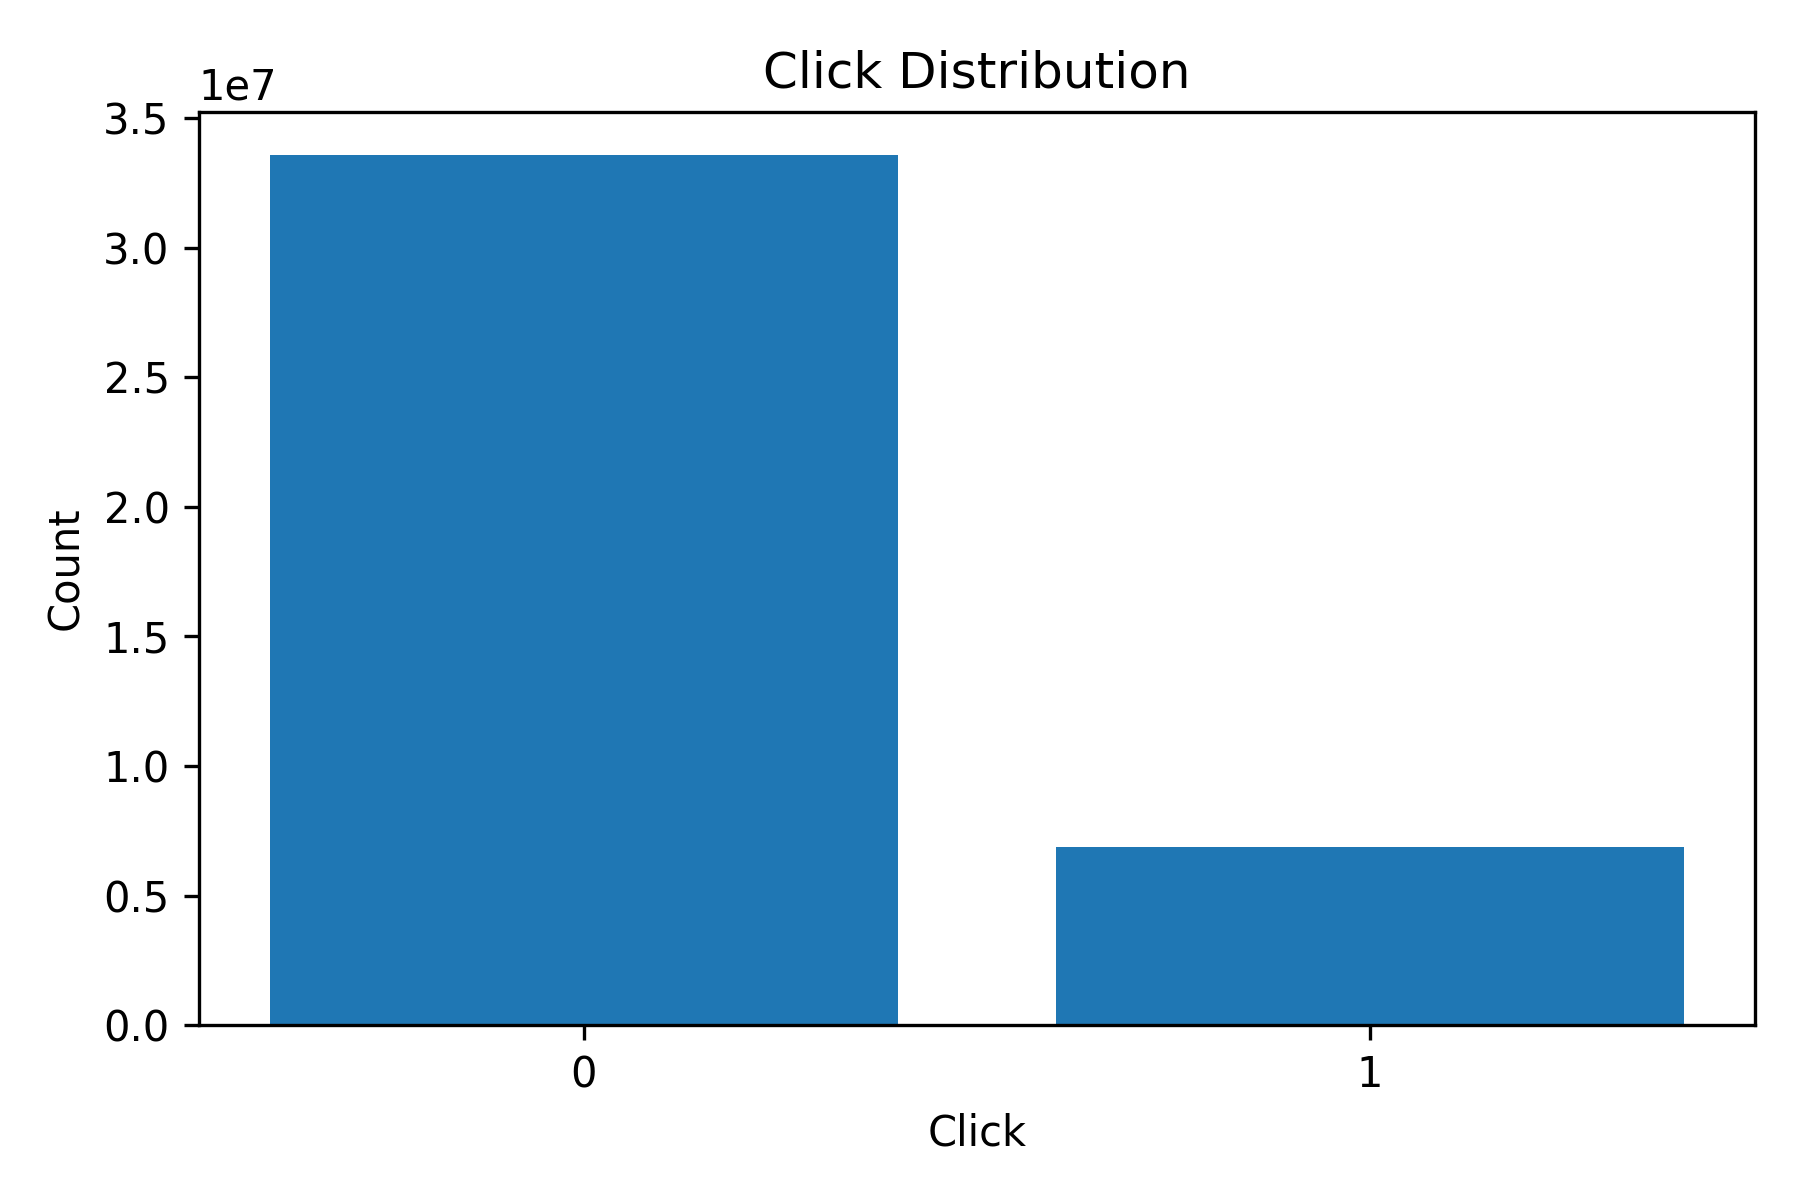

In [23]:
from IPython.display import Image

Image("../results/click_distribution.png")

The dataset contains 40,428,967 advertisement impressions, of which 6,865,066 resulted in clicks and 33,563,901 resulted in non-clicks. This corresponds to an overall click-through rate (CTR) of 16.98%. The distribution demonstrates a moderate class imbalance which is common in advertising datasets since most users view ads without interaction with them. This increases the difficulties of prediction click rates. 

### Figure 2: CTR by Hour of Day

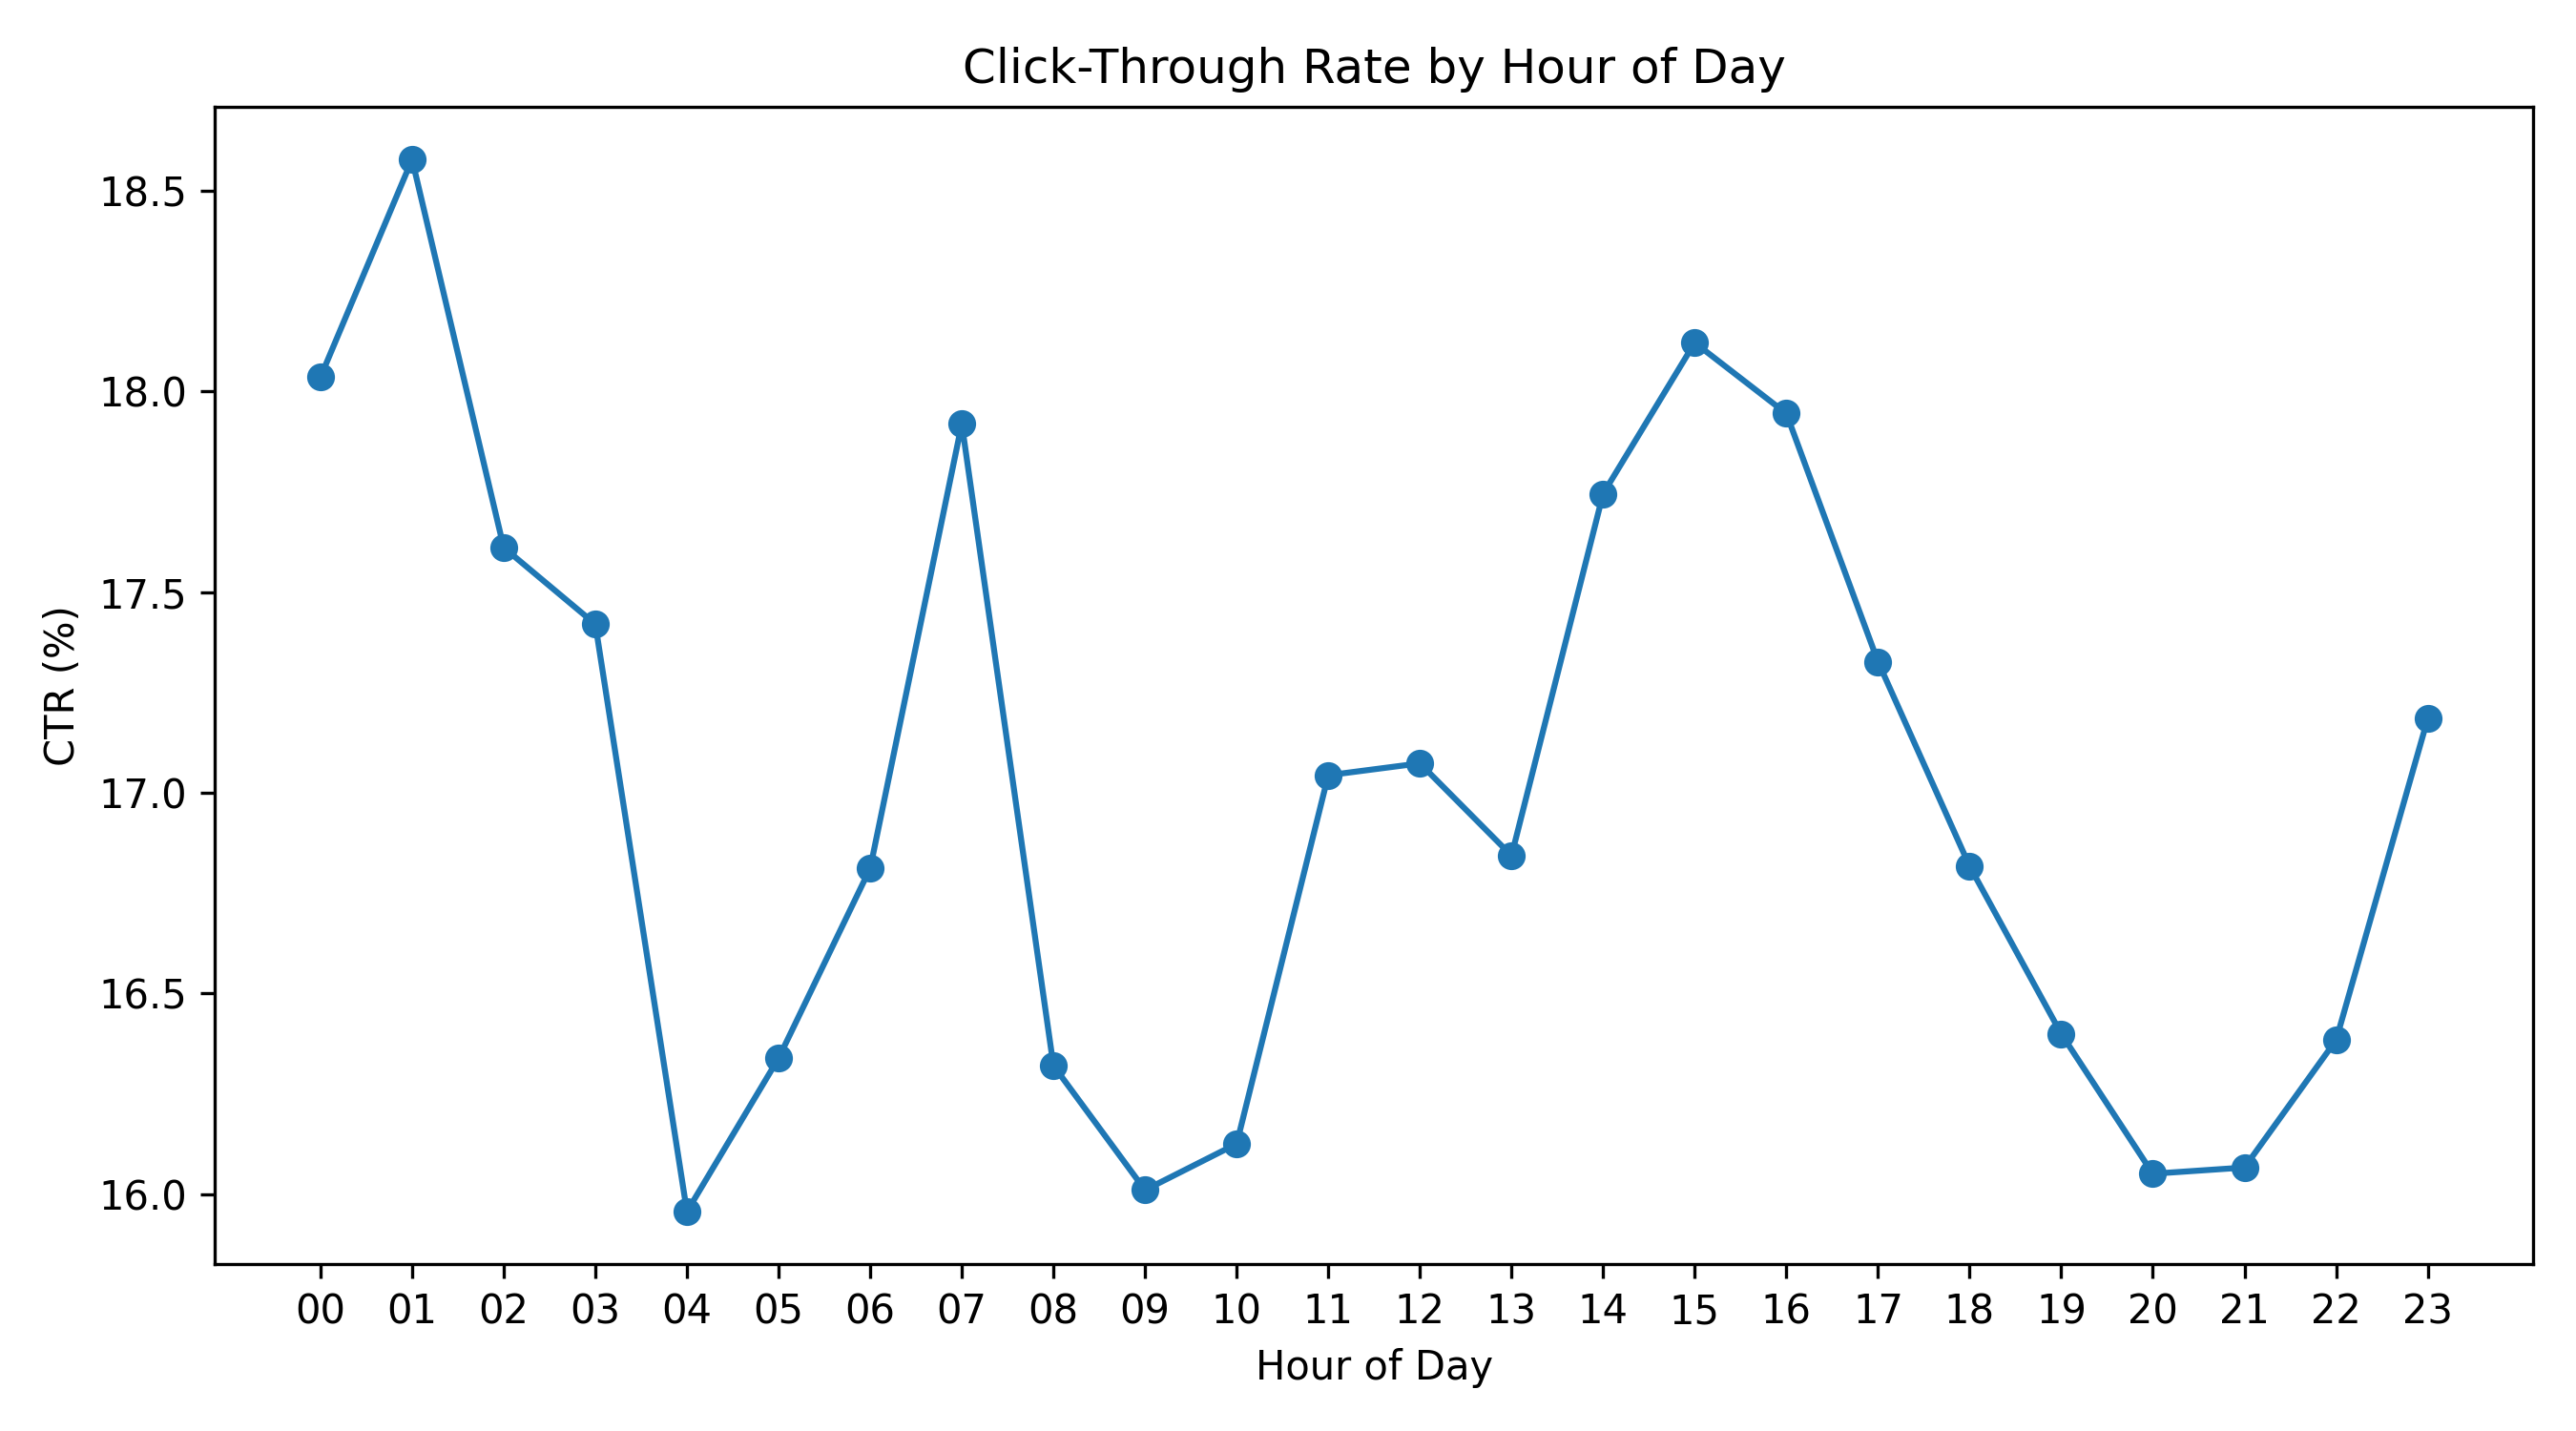

In [24]:
from IPython.display import Image

Image("../results/ctr_by_hour.png")

Figure 2 illustrates how click-through rate varies throughout the day. The highest CTR was observed at 1:00 AM (18.58%), followed by 3:00 PM (18.12%) and 12:00 AM (18.04%). The lowest CTR occurred at 9:00 AM (16.01%), with similarly low values during the evening hours. These results suggest that user engagement with advertisements changes throughout the day and that time-related features provide useful information for CTR prediction

### Figure 3: CTR by Banner Position

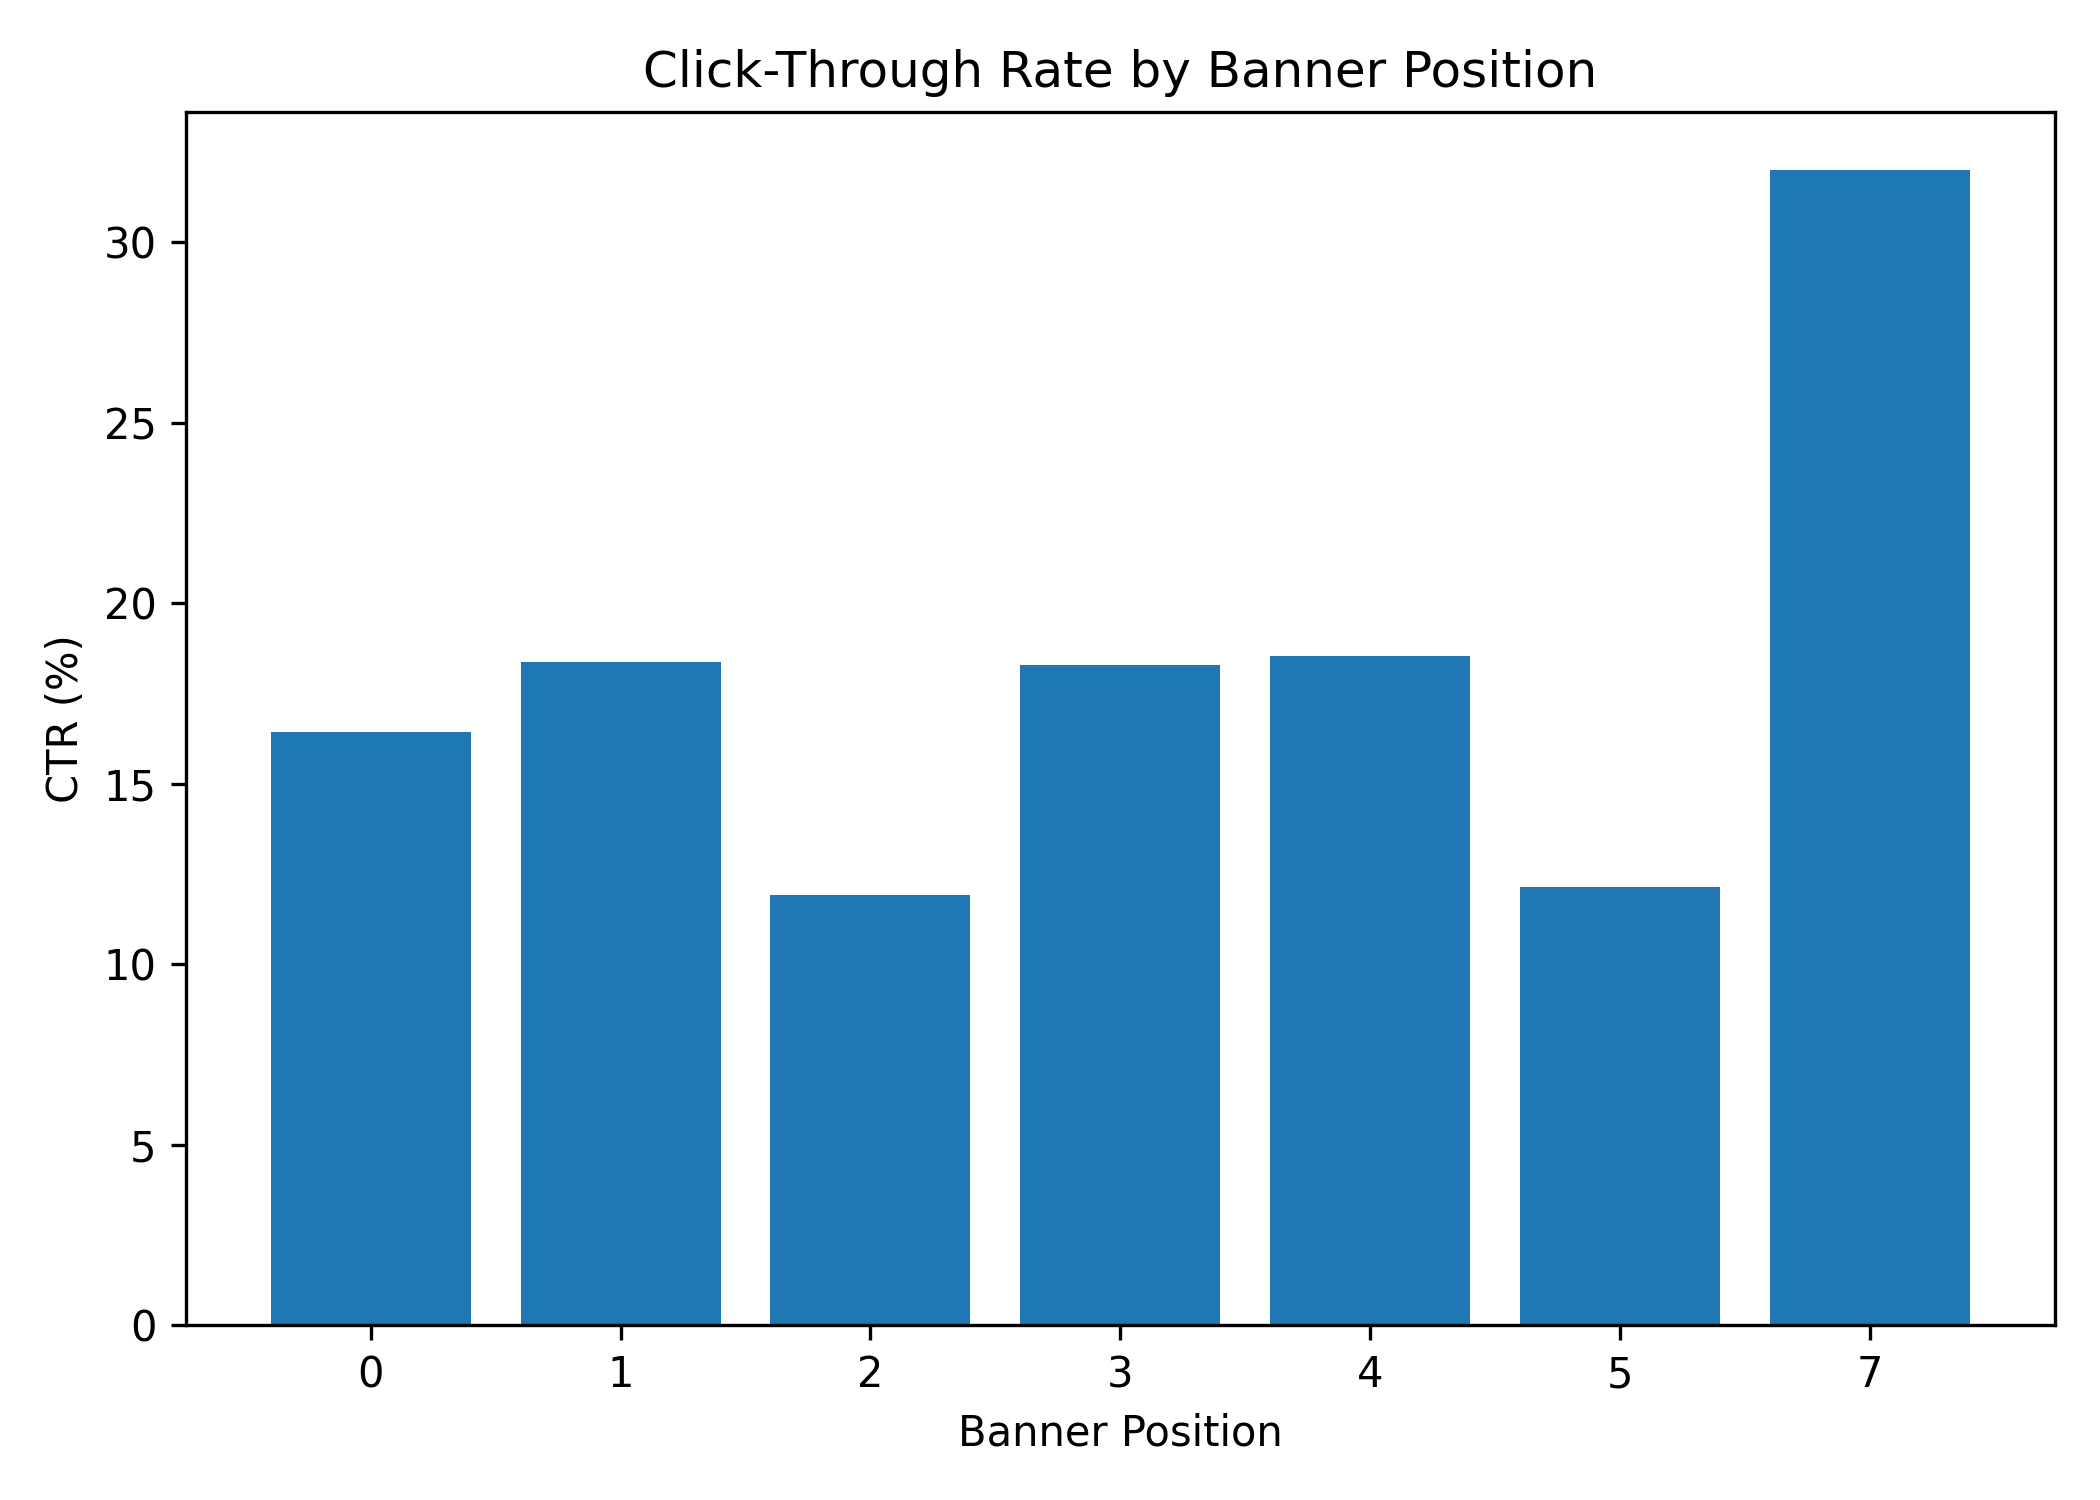

In [25]:
Image("../results/ctr_by_banner_position.png")

Banner position was found to have a substantial impact on advertisement performance. Most impressions occurred in banner positions 0 and 1, which produced CTR values of 16.43% and 18.36%, respectively. However, banner position 7 achieved a remarkably high CTR of approximately 32.01%, nearly double the overall average CTR. These findings indicate that advertisement placement strongly influences user interaction

### Figure 4: CRT by Device Type

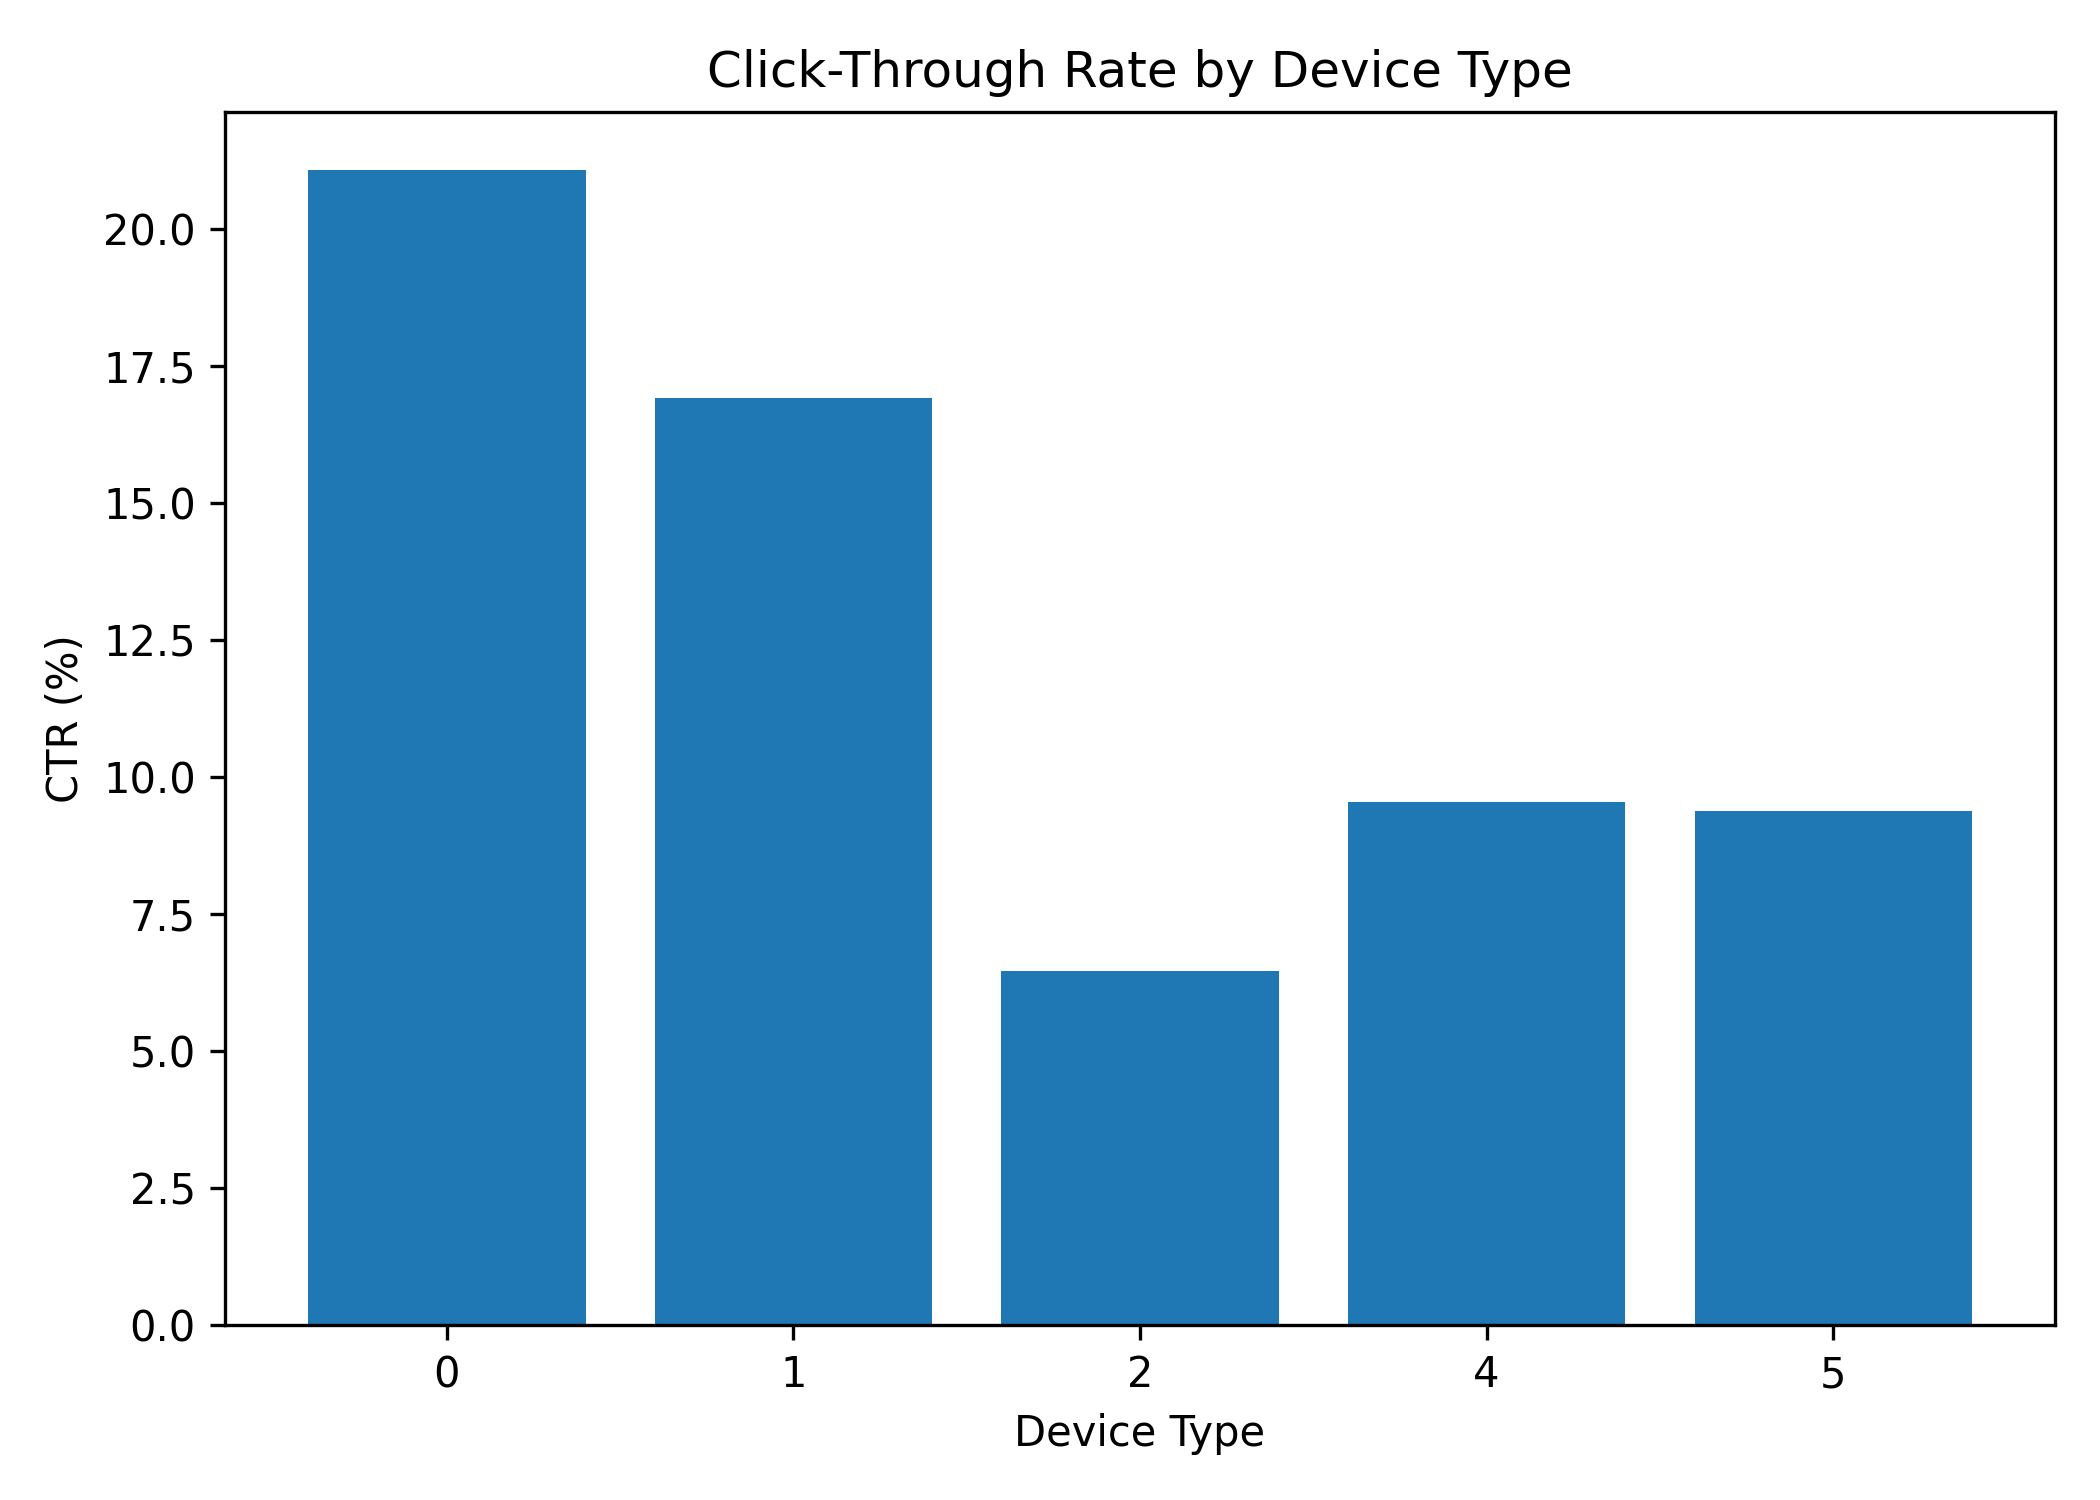

In [26]:
Image("../results/ctr_by_device_type.png")

CTR also varied significantly across device types. Device type 0 achieved the highest CTR at approximately 21.07%, while device type 1, which represented the majority of observations, produced a CTR of 16.92%. Device types 4 and 5 generated substantially lower CTR values of approximately 9.54% and 9.38%, respectively.

## 4.2 Machine Learning Results

Four supervised learning models were trained and evaluated using the processed dataset. Model performance was measured using Area Under the Receiver Operating Characteristic Curve (AUC), where larger values indicate stronger predictive performance.

### Logistic Regression Results

AUC = 0.6459

Logistic Regression served as the baseline model for this study. Despite its relatively simple structure, the model achieved a respectable AUC score of 0.6459. This result indicates that linear relationships among the selected features provide meaningful information for predicting advertisement clicks.

### Decision Tree Results

AUC = 0.4552

The Decision Tree classifier produced the lowest performance among all evaluated models. An AUC score below 0.50 suggests that the model struggled to distinguish between click and non-click observations. One possible explanation is underfitting, where the tree was unable to capture the complex relationships present within the dataset. Given the high dimensionality and large number of categorical variables, a single decision tree appears insufficient for this CTR prediction task.

### Random Forest Results

AUC = 0.6495

Random Forest achieved an AUC score of 0.6495, representing a small improvement over Logistic Regression. By combining multiple decision trees into an ensemble, Random Forest was able to reduce variance and improve predictive stability.

### Gradient Boosted Trees Results

AUC = 0.6895

Gradient Boosted Trees achieved the strongest performance among all evaluated models, producing an AUC score of 0.6895. The boosting process allowed the model to sequentially correct errors made by previous trees and capture complex non-linear relationships within the data. The substantial improvement over both Logistic Regression and Random Forest indicates that boosting methods are particularly effective for CTR prediction problems involving large-scale advertising data.

---

## 4.3 Model Comparison

### Table: Model Performance

| Model                  | AUC    |
| ---------------------- | ------ |
| Decision Tree          | 0.4552 |
| Logistic Regression    | 0.6459 |
| Random Forest          | 0.6495 |
| Gradient Boosted Trees | 0.6895 |

### Figure 5: Model Comparison Chart

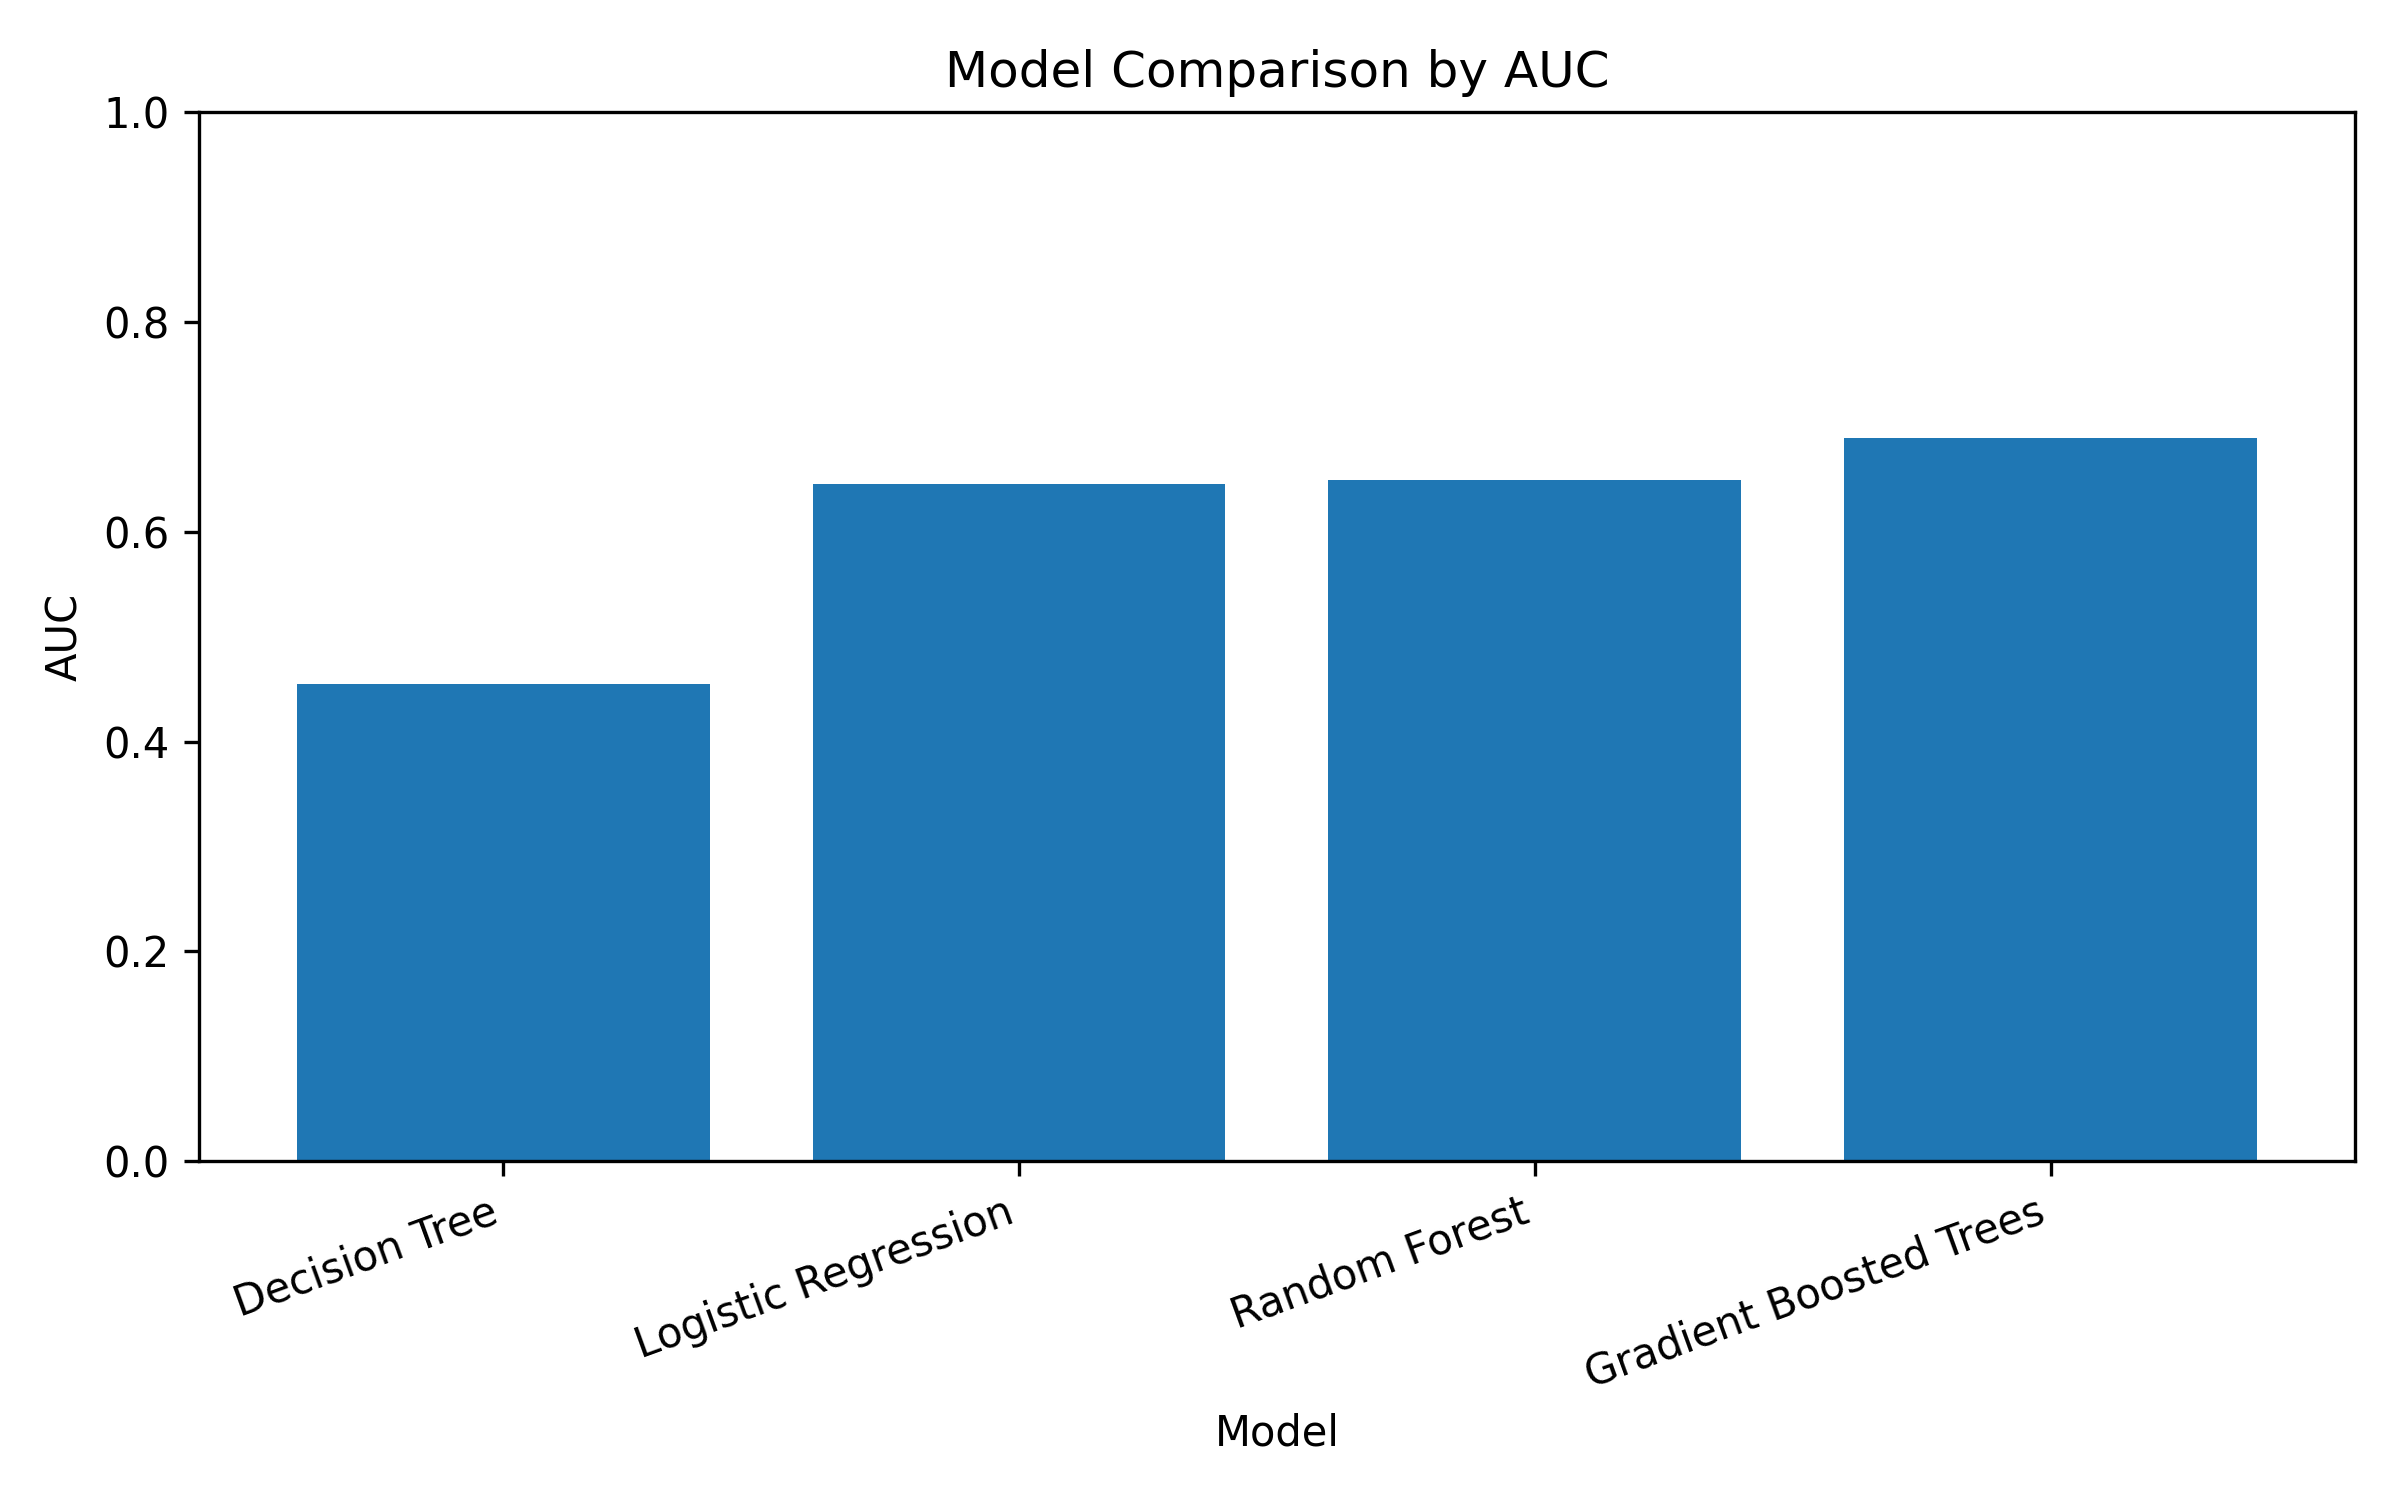

In [27]:
Image("../results/model_comparison_auc.png")

The comparison of different models reveals a clear performance hierarchy. The Decision Tree models preformed the worse failing to capture the user click behavior. Logistic Regression had meaningful predictive information and provided a baseline. Fandom Forest improved performance slightly but the largest improvement was achieved using Gradient Boosted Trees. 

# Conclusion and Future Study

## Conclusion

This project investigated the use of machine learning techniques for predictor CTR using the Avazu Click-Through Rate Prediction dataset. The dataset contained more than 40 million advertising impressions, aiming it an appropriate example of a real big data analytics project. Apache Spark was used to process the dataset, perform exploratory data analysis, and train multiple machine learning models efficiently. 

EDA revealed important patterns in user behavior such as CLR varying through the day suggesting that engagement changes based on time. Advertisement placement was also found to influence CTR where certain banner spots generated higher click rates than others. Device type also played a role on user interaction indicating that it impacts user interaction. 

Four supervised learning algorithms were evaluated: Logistic Regression, Decision Tree, Random Forest, and Gradient Boosted Trees. Logistic Regression han an AUC of 0.6459, while the Decision Tree model performed poorly with an AUC of 0.4552. Random Forest slightly improved predictive accuracy and achieved an AUC of 0.6495. The best performing model was Gradient Boosted Trees which had an AUC of 0.6895. Overall the project demonstrated how machine learning ad big data techniques can be applied to analyze user behavior and improve advertising prediction.

## Future Work

Although initial results were promising there can be more improvement in future. Hyperparameter tuning could further optimize model performance such as tree depth, learning rate, and the number of trees may lead to improved predictive accuracy. Additionally features could be investigated more and derived from interaction effects between variables. As well as training models on larger samples or the complete dataset to improve performance and generalization. 

# References

1. Wang, S., & Cukierski, W. (2014). *Avazu Click-Through Rate Prediction Competition*. Kaggle. Available at: https://www.kaggle.com/competitions/avazu-ctr-prediction

2. Apache Software Foundation. (2026). *Apache Spark Documentation*. Available at: https://spark.apache.org/docs/latest/

3. Apache Software Foundation. (2026). *Spark MLlib: Machine Learning Library*. Available at: https://spark.apache.org/mllib/

# Appendix

## Appendix A: Python Code

The following Python scripts were developed as part of this project:

- `load_data.py` – Loads the Avazu dataset into Apache Spark.
- `eda.py` – Performs exploratory data analysis.
- `train_logistic.py` – Trains the Logistic Regression model.
- `train_tree.py` – Trains the Decision Tree model.
- `train_rf.py` – Trains the Random Forest model.
- `train_gbt.py` – Trains the Gradient Boosted Trees model.

The complete source code is available in the project repository: https://github.com/Quinland03/avazu-ctr-prediction

---

## Appendix B: Additional Graphs

The following visualizations were generated during the analysis:

- Click Distribution
- CTR by Hour of Day
- CTR by Banner Position
- CTR by Device Type
- Model Comparison by AUC

Additional figures may be found in the `results/` directory https://github.com/Quinland03/avazu-ctr-prediction.

---

## Appendix C: Mathematical Formulae

### Logarithmic Loss

The competition evaluation metric is:

$$
\text{LogLoss}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

where:

- $y_i$ is the true class label
- $p_i$ is the predicted probability of a click